In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Build MLP model
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(x_train, y_train, epochs=3, validation_data=(x_test, y_test))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9252 - loss: 0.2630 - val_accuracy: 0.9589 - val_loss: 0.1363
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9651 - loss: 0.1173 - val_accuracy: 0.9690 - val_loss: 0.0993
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9762 - loss: 0.0820 - val_accuracy: 0.9738 - val_loss: 0.0821


In [ ]:
# Install LIME (only for Colab)
import sys
if 'google.colab' in sys.modules:
    !pip install lime

# Imports
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic

# -----------------------------
# 1. Select Test Image
# -----------------------------
image = x_test[0]   # shape (28, 28)

# Expand dims for model prediction
image_expanded = np.expand_dims(image, axis=0)   # (1, 28, 28)

# Prediction
pred = model.predict(image_expanded)
predicted_class = np.argmax(pred)
print("Predicted Class:", predicted_class)

# -----------------------------
# 2. Prepare Image for LIME
# -----------------------------
# Add channel dimension → (28, 28, 1)
lime_input_image = np.expand_dims(image, axis=-1)

# -----------------------------
# 3. Create Explainer
# -----------------------------
explainer = lime_image.LimeImageExplainer()

# -----------------------------
# 4. Define Prediction Function
# -----------------------------
def predict_fn(images):
    # If model expects (batch, 28, 28)
    images = images.squeeze(axis=-1)
    return model.predict(images)

# -----------------------------
# 5. Segmentation Function
# -----------------------------
def segmentation_fn(img):
    return slic(img, convert2lab=False)

# -----------------------------
# 6. Generate Explanation
# -----------------------------
explanation = explainer.explain_instance(
    lime_input_image,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000,
    segmentation_fn=segmentation_fn
)

# -----------------------------
# 7. Get Important Regions
# -----------------------------
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Class: 7


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━

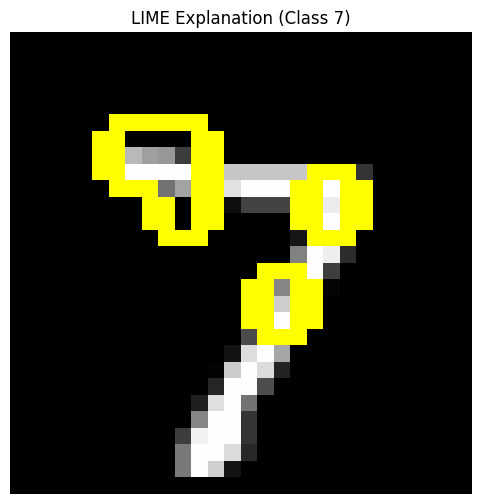

In [ ]:
# -----------------------------
# 8. Display Result
# -----------------------------
plt.figure(figsize=(6,6))
plt.imshow(mark_boundaries(temp.squeeze(), mask))
plt.title(f"LIME Explanation (Class {predicted_class})")
plt.axis('off')
plt.show()